In [1]:
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle
import pingouin as pg
 

import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u

from STX3KO_analyses.hse import HSE
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline


In [32]:

rows = []
for cond, mice in zip(('ctrl', 'ko'), (ctrl_mice, ko_mice)):
    for mouse in mice:
        print(mouse)
        sess = u.single_mouse_concat_sessions(mouse, np.arange(6), trial_mat_keys=['F_dff'], timeseries_keys=['F_dff'])
        rz_early = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_early['tfront'])[0], np.argwhere(sess.rzone_early['tback']<=sess.trial_matrices['bin_edges'][1:])[0] )
        rz_late = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_late['tfront'])[0], 29 )

        if sess.novel_arm == 1: 
            rz_nov = rz_late
            rz_fam = rz_early
        else: 
            rz_nov = rz_early
            rz_fam = rz_late

        pc_mask = sess.fam_place_cell_mask()+sess.nov_place_cell_mask()

        nov_mask= sess.trial_info['LR']==sess.novel_arm
        for day in range(5):

            day_mask = sess.trial_info['sess_num']==day
            # pc_mask = sess.place_cell_info[-1]['masks'][day] + sess.place_cell_info[1]['masks'][day]
            # place cell peak

            tmat_nov = np.nanmean(sess.trial_matrices['F_dff'][nov_mask*day_mask,:,:][:,:,pc_mask], axis=0)
            maxpos_nov = np.nanargmax(tmat_nov, axis=0)
            rel_pos_nov = maxpos_nov-rz_nov[0]
            rz_cell_nov = (maxpos_nov>=(rz_nov[0]-5)) * (maxpos_nov<=(rz_nov[0]+1))

            tmat_fam = np.nanmean(sess.trial_matrices['F_dff'][~nov_mask*day_mask,:,:][:,:,pc_mask], axis=0)
            maxpos_fam = np.nanargmax(tmat_fam, axis=0)
            rel_pos_fam = maxpos_fam - rz_fam[0]
            rz_cell_fam = (maxpos_fam>=(rz_fam[0]-5)) * (maxpos_fam<=(rz_fam[0]+1))

            r_cell_mask = rz_cell_fam * rz_cell_nov
            o_cell_mask = (rz_cell_fam + rz_cell_nov) * (~r_cell_mask)

            for next_day in range(day+1,6):
                next_day_mask = sess.trial_info['sess_num']==next_day
                for ttype in ('nov', 'fam'):
                    if ttype == 'nov':
                        n_mask = nov_mask
                        rz = rz_nov
                        day_mat = tmat_nov
                        day_rel_pos  =rel_pos_nov
                        day_pos = maxpos_nov
                    else:
                        n_mask = ~nov_mask
                        rz = rz_fam
                        day_mat = tmat_fam
                        day_rel_pos = rel_pos_nov
                        day_pos = maxpos_fam
                    
                    next_day_tmat = np.nanmean(sess.trial_matrices['F_dff'][n_mask*next_day_mask,:,:][:,:,pc_mask],axis=0)
                    next_day_pos = np.nanargmax(next_day_tmat,axis=0)
                    next_day_rel_pos = next_day_pos-rz[0]
                    
                    next_day_corr = np.zeros([next_day_tmat.shape[1],])
                    for cell in range(next_day_tmat.shape[1]):
                        r, _ = sp.stats.pearsonr(day_mat[:,cell], next_day_tmat[:,cell])
                        next_day_corr[cell]=r

                    for (d_rp, nd_rp, ndc, d_p, nd_p) in zip(day_rel_pos[r_cell_mask], 
                                            next_day_rel_pos[r_cell_mask],
                                            next_day_corr[r_cell_mask], 
                                            day_pos[r_cell_mask], 
                                            next_day_pos[r_cell_mask]):
                        rows.append({'cond': cond,
                                    'mouse': mouse, 
                                    'day': day,
                                    'next_day': next_day,
                                    'ttype': ttype,
                                    'reward_cell': True,
                                    'day_rel_pos': d_rp,
                                    'next_day_rel_pos': nd_rp,
                                    'next_day_corr': ndc,
                                    'day_pos': d_p,
                                    'next_day_pos': nd_p})
                        
                    for (d_rp, nd_rp, ndc, d_p, nd_p) in zip(day_rel_pos[o_cell_mask], 
                                            next_day_rel_pos[o_cell_mask],
                                            next_day_corr[o_cell_mask],
                                            day_pos[o_cell_mask], 
                                            next_day_pos[o_cell_mask]):
                        rows.append({'cond': cond,
                                    'mouse': mouse, 
                                    'day': day,
                                    'next_day': next_day,
                                    'ttype': ttype,
                                    'reward_cell': False,
                                    'day_rel_pos': d_rp,
                                    'next_day_rel_pos': nd_rp,
                                    'next_day_corr': ndc,
                                    'day_pos': d_p,
                                    'next_day_pos': nd_p})

df = pd.DataFrame(rows)
df['pos_diff']= np.abs(df['next_day_rel_pos']-df['day_rel_pos'])


4467331.1
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
4467331.2
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
4467332.1
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
4467332.2
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
4467333.1
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


05_12_2020 YMaze_LNovel
mCherry6
14_10_2021 YMaze_LNovel
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
mCherry7
14_10_2021 YMaze_LNovel
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
mCherry8
14_10_2021 YMaze_LNovel
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
18_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
mCherry9
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
21_10_2021 YMaze_LNovel
4467975.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


28_09_2020 YMaze_LNovel


...

01_10_2020 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


02_10_2020 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


03_10_2020 YMaze_LNovel
4467975.4
28_09_2020 YMaze_LNovel
29_09_2020 YMaze_LNovel
30_09_2020 YMaze_LNovel
01_10_2020 YMaze_LNovel
02_10_2020 YMaze_LNovel
03_10_2020 YMaze_LNovel
4467975.5
28_09_2020 YMaze_LNovel
29_09_2020 YMaze_LNovel
30_09_2020 YMaze_LNovel
01_10_2020 YMaze_LNovel
02_10_2020 YMaze_LNovel
03_10_2020 YMaze_LNovel
Cre7
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
21_10_2021 YMaze_LNovel
22_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel
Cre9
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
21_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel


In [33]:
df.head()

,cond,mouse,day,next_day,ttype,reward_cell,day_rel_pos,next_day_rel_pos,next_day_corr,day_pos,next_day_pos,pos_diff
0,ctrl,4467331.1,0,1,nov,True,0,-1,0.917341,20,19,1
1,ctrl,4467331.1,0,1,nov,True,-2,-5,0.625234,18,15,3
2,ctrl,4467331.1,0,1,nov,True,0,-1,0.934109,20,19,1
3,ctrl,4467331.1,0,1,nov,True,-1,-1,0.359037,19,19,0
4,ctrl,4467331.1,0,1,nov,True,1,-2,0.320347,21,18,3


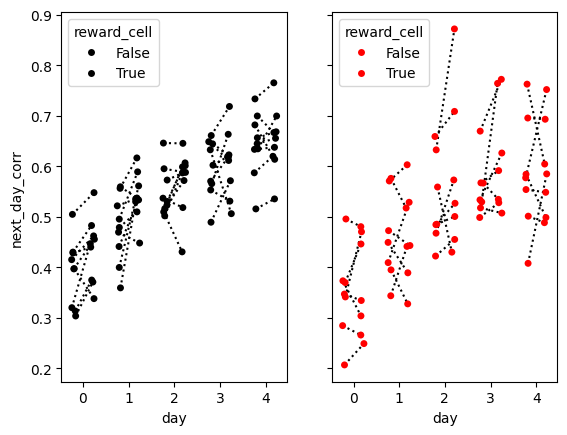

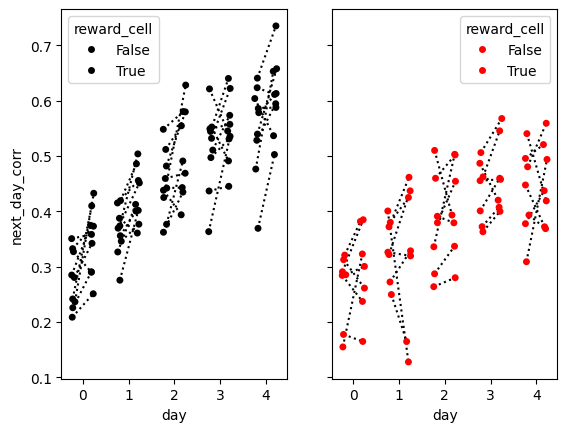

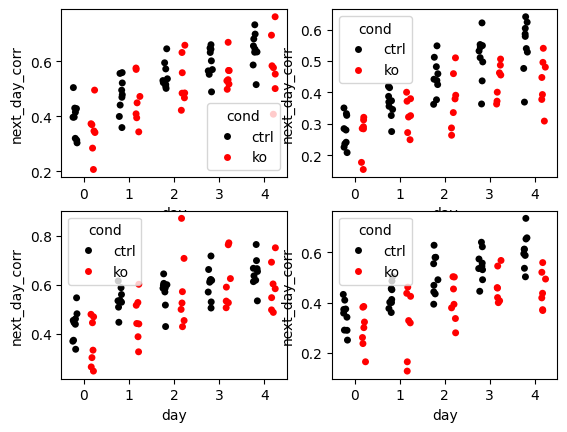

In [34]:
fig, ax = plt.subplots(1,2, sharex=True, sharey=True)

tmp_df = df.groupby(['cond', 'mouse', 'day', 'ttype', 'reward_cell'])['next_day_corr'].mean().reset_index()
_ = sns.stripplot(data=tmp_df.loc[(tmp_df['ttype']=='fam') * (tmp_df['cond']=='ctrl')],
                  x='day',
                  y='next_day_corr',
                  hue='reward_cell',
                  hue_order=[False, True],
                  palette=['black', 'black'],
                  dodge=True, ax=ax[0]
                  )
for d in range(0,10,2):
    for (x0, y0), (x1, y1) in zip(ax[0].collections[d].get_offsets(), ax[0].collections[d+1].get_offsets()):
        ax[0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

_ = sns.stripplot(data=tmp_df.loc[(tmp_df['ttype']=='fam') * (tmp_df['cond']=='ko')],
                  x='day',
                  y='next_day_corr',
                  hue='reward_cell',
                  hue_order=[False, True],
                  palette=['red', 'red'],
                  dodge=True, ax=ax[1]
                  )
for d in range(0,10,2):
    for (x0, y0), (x1, y1) in zip(ax[1].collections[d].get_offsets(), ax[1].collections[d+1].get_offsets()):
        ax[1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)



fig, ax = plt.subplots(1,2, sharex=True, sharey=True)

tmp_df = df.groupby(['cond', 'mouse', 'day', 'ttype', 'reward_cell'])['next_day_corr'].mean().reset_index()
_ = sns.stripplot(data=tmp_df.loc[(tmp_df['ttype']=='nov') * (tmp_df['cond']=='ctrl')],
                  x='day',
                  y='next_day_corr',
                  hue='reward_cell',
                  hue_order=[False, True],
                  palette=['black', 'black'],
                  dodge=True, ax=ax[0]
                  )
for d in range(0,10,2):
    for (x0, y0), (x1, y1) in zip(ax[0].collections[d].get_offsets(), ax[0].collections[d+1].get_offsets()):
        ax[0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

_ = sns.stripplot(data=tmp_df.loc[(tmp_df['ttype']=='nov') * (tmp_df['cond']=='ko')],
                  x='day',
                  y='next_day_corr',
                  hue='reward_cell',
                  hue_order=[False, True],
                  palette=['red', 'red'],
                  dodge=True, ax=ax[1]
                  )
for d in range(0,10,2):
    for (x0, y0), (x1, y1) in zip(ax[1].collections[d].get_offsets(), ax[1].collections[d+1].get_offsets()):
        ax[1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

fig, ax = plt.subplots(2,2)
_ = sns.stripplot(data=tmp_df.loc[(tmp_df['ttype']=='fam') * (tmp_df['reward_cell']==False)],
                  x='day',
                  y='next_day_corr',
                  hue='cond',
                  hue_order=['ctrl', 'ko'],
                  palette=['black', 'red'],
                  dodge=True, ax=ax[0,0]
                  )

_ = sns.stripplot(data=tmp_df.loc[(tmp_df['ttype']=='nov') * (tmp_df['reward_cell']==False)],
                  x='day',
                  y='next_day_corr',
                  hue='cond',
                  hue_order=['ctrl', 'ko'],
                  palette=['black', 'red'],
                  dodge=True, ax=ax[0,1]
                  )
_ = sns.stripplot(data=tmp_df.loc[(tmp_df['ttype']=='fam') * (tmp_df['reward_cell']==True)],
                  x='day',
                  y='next_day_corr',
                  hue='cond',
                  hue_order=['ctrl', 'ko'],
                  palette=['black', 'red'],
                  dodge=True, ax=ax[1,0]
                  )

_ = sns.stripplot(data=tmp_df.loc[(tmp_df['ttype']=='nov') * (tmp_df['reward_cell']==True)],
                  x='day',
                  y='next_day_corr',
                  hue='cond',
                  hue_order=['ctrl', 'ko'],
                  palette=['black', 'red'],
                  dodge=True, ax=ax[1,1]
                  )


58.0 0.003321678321678322
46.0 0.14160839160839161
45.0 0.1737762237762238
43.0 0.2522727272727273


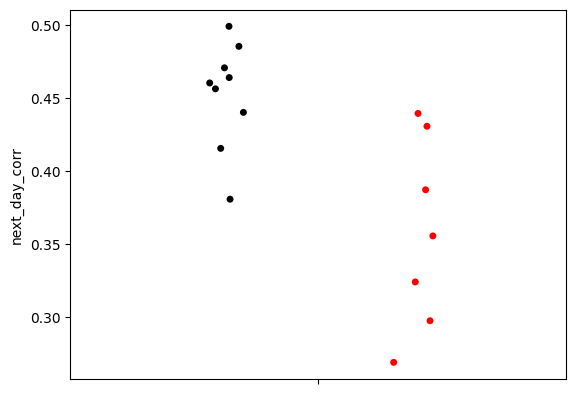

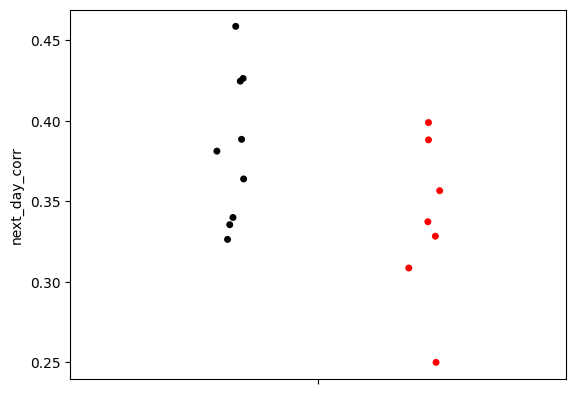

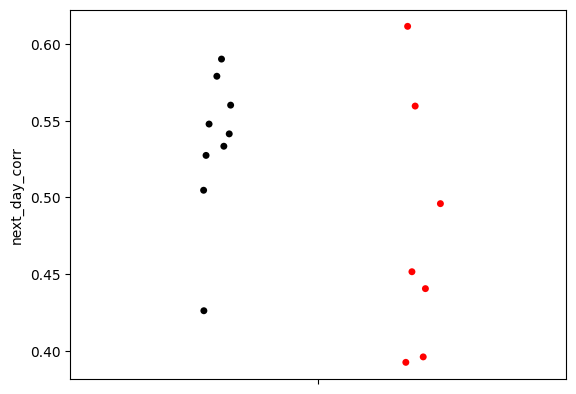

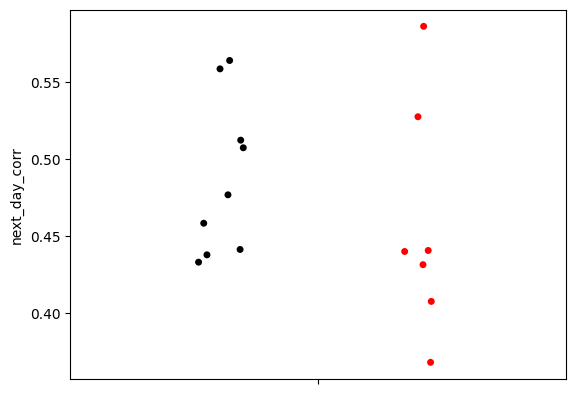

In [35]:
tmp_df = df.groupby(['cond', 'mouse', 'ttype', 'reward_cell'])['next_day_corr'].mean().reset_index()
fig, ax = plt.subplots()
sns.stripplot(data = tmp_df.loc[(tmp_df['ttype']=='nov') * (tmp_df['reward_cell']==True)],
              y='next_day_corr', hue='cond',hue_order=['ctrl','ko'],
              palette=['black','red'],ax=ax, legend=False, dodge=True)

mask = (tmp_df['ttype']=='nov') * (tmp_df['reward_cell']==True)
r,p = sp.stats.mannwhitneyu(tmp_df.loc[mask*(tmp_df['cond']=='ctrl'), 'next_day_corr'],
                            tmp_df.loc[mask*(tmp_df['cond']=='ko'), 'next_day_corr'])
print(r,p)


fig, ax = plt.subplots()
sns.stripplot(data = tmp_df.loc[(tmp_df['ttype']=='nov') * (tmp_df['reward_cell']==False)],
              y='next_day_corr', hue='cond',hue_order=['ctrl','ko'],
              palette=['black','red'],ax=ax, legend=False, dodge=True)

mask = (tmp_df['ttype']=='nov') * (tmp_df['reward_cell']==False)
r,p = sp.stats.mannwhitneyu(tmp_df.loc[mask*(tmp_df['cond']=='ctrl'), 'next_day_corr'],
                            tmp_df.loc[mask*(tmp_df['cond']=='ko'), 'next_day_corr'])
print(r,p)


tmp_df = df.groupby(['cond', 'mouse', 'ttype', 'reward_cell'])['next_day_corr'].mean().reset_index()
fig, ax = plt.subplots()
sns.stripplot(data = tmp_df.loc[(tmp_df['ttype']=='fam') * (tmp_df['reward_cell']==True)],
              y='next_day_corr', hue='cond',hue_order=['ctrl','ko'],
              palette=['black','red'],ax=ax, legend=False, dodge=True)

mask = (tmp_df['ttype']=='fam') * (tmp_df['reward_cell']==True)
r,p = sp.stats.mannwhitneyu(tmp_df.loc[mask*(tmp_df['cond']=='ctrl'), 'next_day_corr'],
                            tmp_df.loc[mask*(tmp_df['cond']=='ko'), 'next_day_corr'])
print(r,p)


fig, ax = plt.subplots()
sns.stripplot(data = tmp_df.loc[(tmp_df['ttype']=='fam') * (tmp_df['reward_cell']==False)],
              y='next_day_corr', hue='cond',hue_order=['ctrl','ko'],
              palette=['black','red'],ax=ax, legend=False, dodge=True)

mask = (tmp_df['ttype']=='fam') * (tmp_df['reward_cell']==False)
r,p = sp.stats.mannwhitneyu(tmp_df.loc[mask*(tmp_df['cond']=='ctrl'), 'next_day_corr'],
                            tmp_df.loc[mask*(tmp_df['cond']=='ko'), 'next_day_corr'])
print(r,p)

In [36]:
aov = pg.rm_anova(data=df.loc[df['cond']=='ctrl'], subject='mouse',
                  within=['day','reward_cell'], dv = 'next_day_corr')
aov

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,day,0.700414,4,32,0.175103,94.137894,3.159668e-17,1.759787e-09,0.748507,0.493881
1,reward_cell,0.044371,1,8,0.044371,33.402369,4.147642e-04,4.147642e-04,0.158636,1.000000
2,day * reward_cell,0.005010,4,32,0.001252,1.006801,4.184892e-01,4.006099e-01,0.020845,0.652317


In [37]:
aov = pg.rm_anova(data=df.loc[df['cond']=='ko'], subject='mouse',
                  within=[ 'reward_cell'], dv = 'next_day_corr')
aov

,Source,ddof1,ddof2,F,p-unc,ng2,eps
0,reward_cell,1,6,2.653256,0.154461,0.04504,1.0


In [38]:
aov = pg.mixed_anova(data = df.loc[(df['ttype']=='nov')], subject='mouse',
                     within='reward_cell', between='cond', dv='next_day_corr')
aov


,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,cond,0.038220,1,14,0.038220,9.692384,0.007629,0.409093,NaN
1,reward_cell,0.018103,1,14,0.018103,19.368106,0.000604,0.580438,1.0
2,Interaction,0.004988,1,14,0.004988,5.336810,0.036638,0.275992,NaN


In [39]:
aov = pg.mixed_anova(data = df.loc[(df['ttype']=='nov')*(df['reward_cell']==True)], subject='mouse',
                     within='day', between='cond', dv='next_day_corr')
aov

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,cond,0.196725,1,14,0.196725,17.288974,9.663845e-04,0.552558,NaN
1,day,0.526803,4,56,0.131701,29.306851,3.697483e-13,0.676726,0.73333
2,Interaction,0.022509,4,56,0.005627,1.252228,2.996495e-01,0.082101,NaN


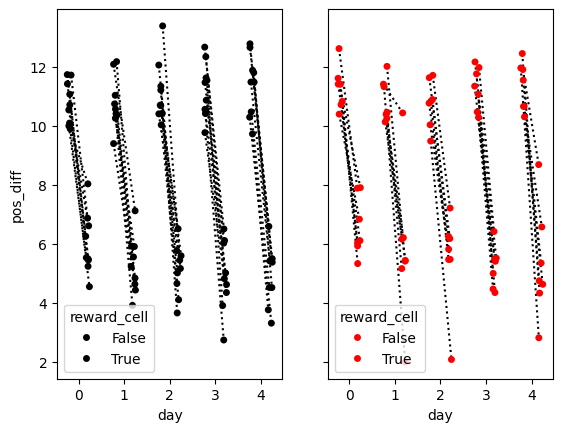

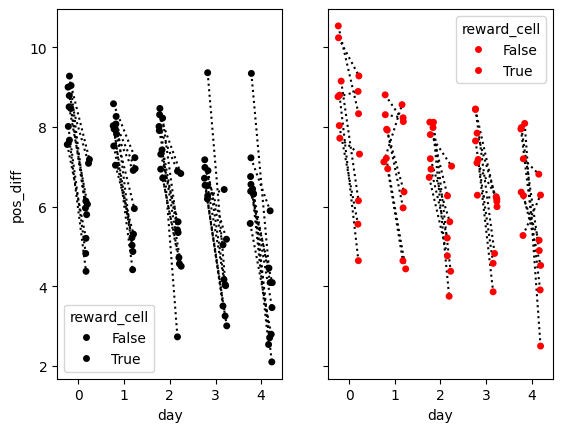

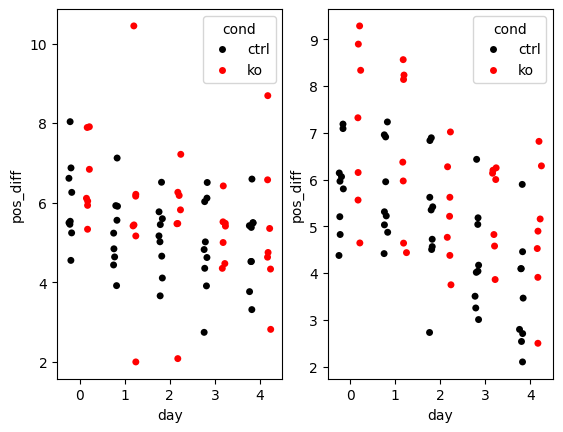

In [40]:
fig, ax = plt.subplots(1,2, sharex=True, sharey=True)

tmp_df = df.groupby(['cond', 'mouse', 'day', 'ttype', 'reward_cell'])['pos_diff'].mean().reset_index()
_ = sns.stripplot(data=tmp_df.loc[(tmp_df['ttype']=='fam') * (tmp_df['cond']=='ctrl')],
                  x='day',
                  y='pos_diff',
                  hue='reward_cell',
                  hue_order=[False, True],
                  palette=['black', 'black'],
                  dodge=True, ax=ax[0]
                  )
for d in range(0,10,2):
    for (x0, y0), (x1, y1) in zip(ax[0].collections[d].get_offsets(), ax[0].collections[d+1].get_offsets()):
        ax[0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

_ = sns.stripplot(data=tmp_df.loc[(tmp_df['ttype']=='fam') * (tmp_df['cond']=='ko')],
                  x='day',
                  y='pos_diff',
                  hue='reward_cell',
                  hue_order=[False, True],
                  palette=['red', 'red'],
                  dodge=True, ax=ax[1]
                  )
for d in range(0,10,2):
    for (x0, y0), (x1, y1) in zip(ax[1].collections[d].get_offsets(), ax[1].collections[d+1].get_offsets()):
        ax[1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)



fig, ax = plt.subplots(1,2, sharex=True, sharey=True)

tmp_df = df.groupby(['cond', 'mouse', 'day', 'ttype', 'reward_cell'])['pos_diff'].mean().reset_index()
_ = sns.stripplot(data=tmp_df.loc[(tmp_df['ttype']=='nov') * (tmp_df['cond']=='ctrl')],
                  x='day',
                  y='pos_diff',
                  hue='reward_cell',
                  hue_order=[False, True],
                  palette=['black', 'black'],
                  dodge=True, ax=ax[0]
                  )
for d in range(0,10,2):
    for (x0, y0), (x1, y1) in zip(ax[0].collections[d].get_offsets(), ax[0].collections[d+1].get_offsets()):
        ax[0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

_ = sns.stripplot(data=tmp_df.loc[(tmp_df['ttype']=='nov') * (tmp_df['cond']=='ko')],
                  x='day',
                  y='pos_diff',
                  hue='reward_cell',
                  hue_order=[False, True],
                  palette=['red', 'red'],
                  dodge=True, ax=ax[1]
                  )
for d in range(0,10,2):
    for (x0, y0), (x1, y1) in zip(ax[1].collections[d].get_offsets(), ax[1].collections[d+1].get_offsets()):
        ax[1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

fig, ax = plt.subplots(1,2)
_ = sns.stripplot(data=tmp_df.loc[(tmp_df['ttype']=='fam') * (tmp_df['reward_cell']==True)],
                  x='day',
                  y='pos_diff',
                  hue='cond',
                  hue_order=['ctrl', 'ko'],
                  palette=['black', 'red'],
                  dodge=True, ax=ax[0]
                  )

_ = sns.stripplot(data=tmp_df.loc[(tmp_df['ttype']=='nov') * (tmp_df['reward_cell']==True)],
                  x='day',
                  y='pos_diff',
                  hue='cond',
                  hue_order=['ctrl', 'ko'],
                  palette=['black', 'red'],
                  dodge=True, ax=ax[1]
                  )


In [41]:
# aov = pg.mixed_anova(data = df.loc[(df['reward_cell']==True)], subject='mouse',
#                      within='day', between='cond', dv='pos_diff')
# aov

res = pg.pairwise_tests(data = df.loc[df['reward_cell']==True], subject='mouse',
                        within='ttype', between='cond', dv='pos_diff', padjust='holm', parametric=False)
res

,Contrast,ttype,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,ttype,-,fam,nov,True,False,NaN,62.0,two-sided,0.781952,NaN,NaN,-0.117951
1,cond,-,ctrl,ko,False,False,6.0,NaN,two-sided,0.005245,NaN,NaN,-1.530524
2,ttype * cond,fam,ctrl,ko,False,False,23.0,NaN,two-sided,0.407867,0.407867,holm,-0.611732
3,ttype * cond,nov,ctrl,ko,False,False,14.0,NaN,two-sided,0.071154,0.142308,holm,-1.044336


In [42]:
df.head()

,cond,mouse,day,next_day,ttype,reward_cell,day_rel_pos,next_day_rel_pos,next_day_corr,day_pos,next_day_pos,pos_diff
0,ctrl,4467331.1,0,1,nov,True,0,-1,0.917341,20,19,1
1,ctrl,4467331.1,0,1,nov,True,-2,-5,0.625234,18,15,3
2,ctrl,4467331.1,0,1,nov,True,0,-1,0.934109,20,19,1
3,ctrl,4467331.1,0,1,nov,True,-1,-1,0.359037,19,19,0
4,ctrl,4467331.1,0,1,nov,True,1,-2,0.320347,21,18,3


# Correlation across days

In [43]:
# correlation matrices across days

corr_mat = {}
for cond, mice  in zip(('ctrl', 'ko'), (ctrl_mice, ko_mice)):

    corr_mat[cond] = {'fam': {'rr_cell': None,
                              'tr_cell': None},
                      'nov': {'rr_cell': None,
                              'tr_cell': None}
                     }

    for ttype in ('fam', 'nov'):
        for reward_cell in (False, True):
            mat = np.nan*np.zeros([6,6, len(mice)])
            for day in range(5):
                for next_day in range(day+1, 6):
                
                    mask = (df['cond']==cond) * (df['day']==day) * (df['next_day']==next_day) * (df['ttype']==ttype) * (df['reward_cell']==reward_cell)

                    tmp_df = df.loc[mask].groupby(['mouse', 'reward_cell'])['next_day_corr'].mean().reset_index()

                    mat[day, next_day,:] = tmp_df['next_day_corr'].values

            if reward_cell:
                corr_mat[cond][ttype]['rr_cell'] = mat
            else:
                corr_mat[cond][ttype]['tr_cell'] = mat




/tmp/ipykernel_306035/3850397130.py:6: RuntimeWarning: Mean of empty slice
  h = ax[i,0].imshow(np.nanmean(tr_mat,axis=-1), cmap='Greys', vmin=0, vmax=.7)
/tmp/ipykernel_306035/3850397130.py:11: RuntimeWarning: Mean of empty slice
  h=ax[i,1].imshow(np.nanmean(rr_mat,axis=-1), cmap='Greys', vmin=0, vmax=.7)
/tmp/ipykernel_306035/3850397130.py:16: RuntimeWarning: Mean of empty slice
  h=ax[i,2].imshow(np.nanmean(diff_mat, axis=-1), cmap='PuOr', vmin=-.1, vmax=.1)


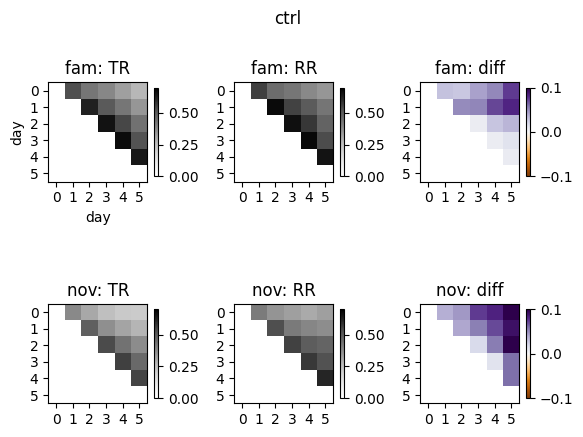

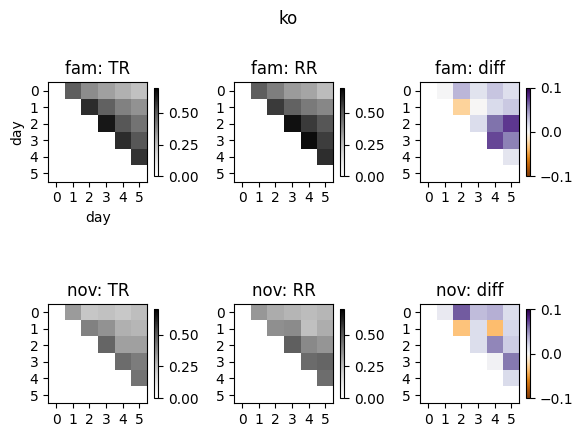

In [44]:
for cond in ('ctrl', 'ko'):
    fig, ax = plt.subplots(2,3)
    fig.subplots_adjust(wspace=.5, hspace=.5)
    for i, ttype in enumerate(('fam', 'nov')):
        tr_mat = corr_mat[cond][ttype]['tr_cell']
        h = ax[i,0].imshow(np.nanmean(tr_mat,axis=-1), cmap='Greys', vmin=0, vmax=.7)
        ax[i,0].set_title(f'{ttype}: TR')
        fig.colorbar(h, shrink=.6)

        rr_mat = corr_mat[cond][ttype]['rr_cell']
        h=ax[i,1].imshow(np.nanmean(rr_mat,axis=-1), cmap='Greys', vmin=0, vmax=.7)
        ax[i,1].set_title(f'{ttype}: RR')
        fig.colorbar(h, shrink=.6)

        diff_mat = rr_mat-tr_mat
        h=ax[i,2].imshow(np.nanmean(diff_mat, axis=-1), cmap='PuOr', vmin=-.1, vmax=.1)
        ax[i,2].set_title(f'{ttype}: diff')
        fig.colorbar(h, shrink=.6)

    fig.suptitle(cond)

    for a in ax.flatten():
        a.set_xticks(np.arange(6))
        a.set_yticks(np.arange(6))
    ax[0,0].set_xlabel('day')
    ax[0,0].set_ylabel('day')

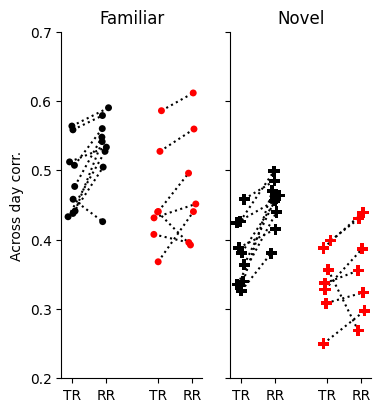

In [45]:

fig, ax = plt.subplots(1,2,figsize=[4,4.5], sharex=True, sharey=True)

tmp_df = df.groupby(['cond', 'mouse', 'ttype', 'reward_cell'])['next_day_corr'].mean().reset_index()
tmp_df['tmp_x'] = 1.*(tmp_df['cond']=='ko')
sns.stripplot(data = tmp_df.loc[ (tmp_df['cond']=='ctrl') * (tmp_df['ttype']=='fam')],
              x='tmp_x', y='next_day_corr', hue='reward_cell',hue_order=[False,True],
              palette=['black','black'],ax=ax[0], legend=False, dodge=True)
d=0
for (x0, y0), (x1, y1) in zip(ax[0].collections[d].get_offsets(), ax[0].collections[d+1].get_offsets()):
    ax[0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

sns.stripplot(data = tmp_df.loc[ (tmp_df['cond']=='ctrl') * (tmp_df['ttype']=='nov')],
              x='tmp_x', y='next_day_corr', hue='reward_cell',hue_order=[False,True],
              palette=['black','black'],ax=ax[1], legend=False, dodge=True, marker='P', s=8)
d=0
for (x0, y0), (x1, y1) in zip(ax[1].collections[d].get_offsets(), ax[1].collections[d+1].get_offsets()):
    ax[1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

sns.stripplot(data = tmp_df.loc[ (tmp_df['cond']=='ko') * (tmp_df['ttype']=='fam')],
              x='tmp_x', y='next_day_corr', hue='reward_cell',hue_order=[False,True],
              palette=['red','red'],ax=ax[0], legend=False, dodge=True)
d=2
for (x0, y0), (x1, y1) in zip(ax[0].collections[d].get_offsets(), ax[0].collections[d+1].get_offsets()):
    ax[0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

sns.stripplot(data = tmp_df.loc[ (tmp_df['cond']=='ko') * (tmp_df['ttype']=='nov')],
              x='tmp_x', y='next_day_corr', hue='reward_cell',hue_order=[False,True],
              palette=['red','red'],ax=ax[1], legend=False, dodge=True, marker='P', s=8)
d=2
for (x0, y0), (x1, y1) in zip(ax[1].collections[d].get_offsets(), ax[1].collections[d+1].get_offsets()):
    ax[1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

ax[0].set_title('Familiar')
ax[1].set_title('Novel')
for a in ax.flatten():
    a.set_xticks([-.2, .2, .8,1.2], labels=['TR', 'RR', 'TR', 'RR'])

    a.set_ylim([.2,.7])
    
    a.set_ylabel('Across day corr.')
    a.set_xlabel('')

    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

# Place field shift

In [46]:
df.head()

,cond,mouse,day,next_day,ttype,reward_cell,day_rel_pos,next_day_rel_pos,next_day_corr,day_pos,next_day_pos,pos_diff
0,ctrl,4467331.1,0,1,nov,True,0,-1,0.917341,20,19,1
1,ctrl,4467331.1,0,1,nov,True,-2,-5,0.625234,18,15,3
2,ctrl,4467331.1,0,1,nov,True,0,-1,0.934109,20,19,1
3,ctrl,4467331.1,0,1,nov,True,-1,-1,0.359037,19,19,0
4,ctrl,4467331.1,0,1,nov,True,1,-2,0.320347,21,18,3


In [84]:
df['abs_rel_pos_shift'] = np.abs(df['day_rel_pos']-df['next_day_rel_pos'])
df['abs_pos_shift'] = np.abs(df['day_pos']-df['next_day_pos'])
df['pos_shift'] = df['next_day_pos']-df['day_pos']

In [89]:
shift_mat = {}
for cond, mice  in zip(('ctrl', 'ko'), (ctrl_mice, ko_mice)):

    shift_mat[cond] = {'fam': {'rr_cell': None,
                              'tr_cell': None},
                      'nov': {'rr_cell': None,
                              'tr_cell': None}
                     }

    for ttype in ('fam', 'nov'):
        for reward_cell in (False, True):
            mat = np.nan*np.zeros([6,6, len(mice)])
            for day in range(5):
                for next_day in range(day+1, 6):
                
                    mask = (df['cond']==cond) * (df['day']==day) * (df['next_day']==next_day) * (df['ttype']==ttype) * (df['reward_cell']==reward_cell)

                    tmp_df = df.loc[mask].groupby(['mouse', 'reward_cell'])['abs_pos_shift'].mean().reset_index()

                    mat[day, next_day,:] = tmp_df['abs_pos_shift'].values

            if reward_cell:
                shift_mat[cond][ttype]['rr_cell'] = mat
            else:
                shift_mat[cond][ttype]['tr_cell'] = mat


/tmp/ipykernel_306035/891720596.py:4: RuntimeWarning: Mean of empty slice
  h=ax[0,0].imshow(np.nanmean(ctrl_rr_mat,axis=-1), cmap='Greys', vmin=0, vmax=10)
/tmp/ipykernel_306035/891720596.py:9: RuntimeWarning: Mean of empty slice
  h=ax[0,1].imshow(np.nanmean(ko_rr_mat,axis=-1), cmap='Greys', vmin=0, vmax=10)


Text(0.5, 1.0, 'nov: Ctrl - KO')

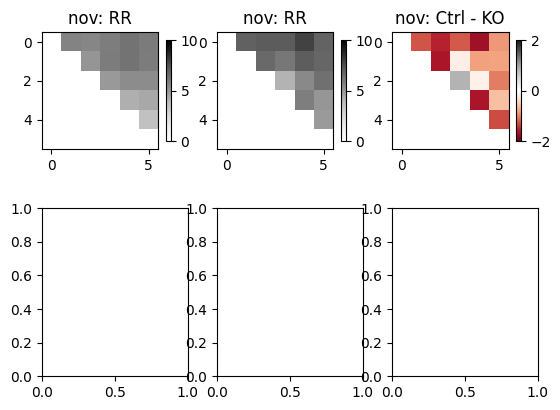

In [99]:
fig, ax = plt.subplots(2,3)

ctrl_rr_mat = shift_mat['ctrl'][ttype]['rr_cell']
h=ax[0,0].imshow(np.nanmean(ctrl_rr_mat,axis=-1), cmap='Greys', vmin=0, vmax=10)
ax[0,0].set_title(f'{ttype}: RR')
fig.colorbar(h, shrink=.6)

ko_rr_mat = shift_mat['ko'][ttype]['rr_cell']
h=ax[0,1].imshow(np.nanmean(ko_rr_mat,axis=-1), cmap='Greys', vmin=0, vmax=10)
ax[0,1].set_title(f'{ttype}: RR')
fig.colorbar(h, shrink=.6)

diff = ctrl_rr_mat.mean(axis=-1) - ko_rr_mat.mean(axis=-1)
h = ax[0,2].imshow(diff, cmap='RdGy', vmin=-2, vmax=2)
fig.colorbar(h, shrink=.6)
ax[0,2].set_title(f'{ttype}: Ctrl - KO')

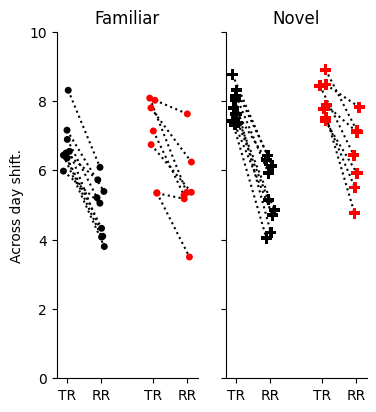

In [85]:
fig, ax = plt.subplots(1,2,figsize=[4,4.5], sharex=True, sharey=True)

tmp_df = df.groupby(['cond', 'mouse', 'ttype', 'reward_cell'])['abs_pos_shift'].mean().reset_index()
tmp_df['tmp_x'] = 1.*(tmp_df['cond']=='ko')
sns.stripplot(data = tmp_df.loc[ (tmp_df['cond']=='ctrl') * (tmp_df['ttype']=='fam')],
              x='tmp_x', y='abs_pos_shift', hue='reward_cell',hue_order=[False,True],
              palette=['black','black'],ax=ax[0], legend=False, dodge=True)
d=0
for (x0, y0), (x1, y1) in zip(ax[0].collections[d].get_offsets(), ax[0].collections[d+1].get_offsets()):
    ax[0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

sns.stripplot(data = tmp_df.loc[ (tmp_df['cond']=='ctrl') * (tmp_df['ttype']=='nov')],
              x='tmp_x', y='abs_pos_shift', hue='reward_cell',hue_order=[False,True],
              palette=['black','black'],ax=ax[1], legend=False, dodge=True, marker='P', s=8)
d=0
for (x0, y0), (x1, y1) in zip(ax[1].collections[d].get_offsets(), ax[1].collections[d+1].get_offsets()):
    ax[1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

sns.stripplot(data = tmp_df.loc[ (tmp_df['cond']=='ko') * (tmp_df['ttype']=='fam')],
              x='tmp_x', y='abs_pos_shift', hue='reward_cell',hue_order=[False,True],
              palette=['red','red'],ax=ax[0], legend=False, dodge=True)
d=2
for (x0, y0), (x1, y1) in zip(ax[0].collections[d].get_offsets(), ax[0].collections[d+1].get_offsets()):
    ax[0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

sns.stripplot(data = tmp_df.loc[ (tmp_df['cond']=='ko') * (tmp_df['ttype']=='nov')],
              x='tmp_x', y='abs_pos_shift', hue='reward_cell',hue_order=[False,True],
              palette=['red','red'],ax=ax[1], legend=False, dodge=True, marker='P', s=8)
d=2
for (x0, y0), (x1, y1) in zip(ax[1].collections[d].get_offsets(), ax[1].collections[d+1].get_offsets()):
    ax[1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

ax[0].set_title('Familiar')
ax[1].set_title('Novel')
for a in ax.flatten():
    a.set_xticks([-.2, .2, .8,1.2], labels=['TR', 'RR', 'TR', 'RR'])

    a.set_ylim([0,10])
    
    a.set_ylabel('Across day shift.')
    a.set_xlabel('')

    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

In [106]:
aov = pg.mixed_anova(df.loc[df['ttype']=='nov'], dv='abs_pos_shift',
                     subject='mouse', within='reward_cell', between='cond')
aov



,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,cond,3.211259,1,14,3.211259,3.389399,8.690447e-02,0.194912,NaN
1,reward_cell,37.804352,1,14,37.804352,132.300111,1.608130e-08,0.904306,1.0
2,Interaction,1.563819,1,14,1.563819,5.472742,3.465693e-02,0.281046,NaN


In [108]:
res = pg.pairwise_tests(df.loc[df['ttype']=='nov'], dv = 'abs_pos_shift',
                        subject='mouse', within='reward_cell', between='cond', parametric=False, within_first=False, padjust='holm')
res

,Contrast,cond,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,cond,-,ctrl,ko,False,False,13.0,NaN,two-sided,0.054895,NaN,NaN,-0.877186
1,reward_cell,-,False,True,True,False,NaN,0.0,two-sided,0.000031,NaN,NaN,2.472262
2,cond * reward_cell,ctrl,False,True,True,False,NaN,0.0,two-sided,0.003906,0.007812,holm,3.327581
3,cond * reward_cell,ko,False,True,True,False,NaN,0.0,two-sided,0.015625,0.015625,holm,1.844184


In [ ]:
# test difference is bigger 

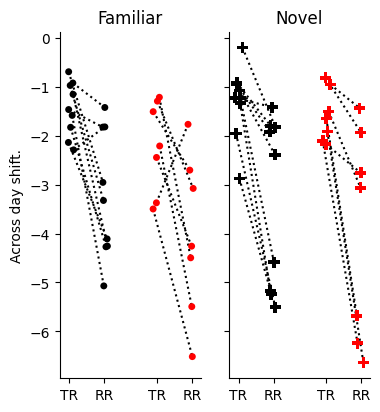

In [87]:
fig, ax = plt.subplots(1,2,figsize=[4,4.5], sharex=True, sharey=True)

tmp_df = df.groupby(['cond', 'mouse', 'ttype', 'reward_cell'])['pos_shift'].mean().reset_index()
tmp_df['tmp_x'] = 1.*(tmp_df['cond']=='ko')
sns.stripplot(data = tmp_df.loc[ (tmp_df['cond']=='ctrl') * (tmp_df['ttype']=='fam')],
              x='tmp_x', y='pos_shift', hue='reward_cell',hue_order=[False,True],
              palette=['black','black'],ax=ax[0], legend=False, dodge=True)
d=0
for (x0, y0), (x1, y1) in zip(ax[0].collections[d].get_offsets(), ax[0].collections[d+1].get_offsets()):
    ax[0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

sns.stripplot(data = tmp_df.loc[ (tmp_df['cond']=='ctrl') * (tmp_df['ttype']=='nov')],
              x='tmp_x', y='pos_shift', hue='reward_cell',hue_order=[False,True],
              palette=['black','black'],ax=ax[1], legend=False, dodge=True, marker='P', s=8)
d=0
for (x0, y0), (x1, y1) in zip(ax[1].collections[d].get_offsets(), ax[1].collections[d+1].get_offsets()):
    ax[1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

sns.stripplot(data = tmp_df.loc[ (tmp_df['cond']=='ko') * (tmp_df['ttype']=='fam')],
              x='tmp_x', y='pos_shift', hue='reward_cell',hue_order=[False,True],
              palette=['red','red'],ax=ax[0], legend=False, dodge=True)
d=2
for (x0, y0), (x1, y1) in zip(ax[0].collections[d].get_offsets(), ax[0].collections[d+1].get_offsets()):
    ax[0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

sns.stripplot(data = tmp_df.loc[ (tmp_df['cond']=='ko') * (tmp_df['ttype']=='nov')],
              x='tmp_x', y='pos_shift', hue='reward_cell',hue_order=[False,True],
              palette=['red','red'],ax=ax[1], legend=False, dodge=True, marker='P', s=8)
d=2
for (x0, y0), (x1, y1) in zip(ax[1].collections[d].get_offsets(), ax[1].collections[d+1].get_offsets()):
    ax[1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

ax[0].set_title('Familiar')
ax[1].set_title('Novel')
for a in ax.flatten():
    a.set_xticks([-.2, .2, .8,1.2], labels=['TR', 'RR', 'TR', 'RR'])

    # a.set_ylim([0,10])
    
    a.set_ylabel('Across day shift.')
    a.set_xlabel('')

    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

In [ ]:


avg_shifts = {}
rel_bins = np.arange(-28,10)
pos_bins = np.arange(30)
for cond, mice in zip(('ctrl', 'ko'), (ctrl_mice, ko_mice)):
    avg_shifts[cond]={}
    for ttype in ('fam', 'nov'):
        avg_shifts[cond][ttype] = {}
        for reward_cell in (False, True):
                avg_shifts[cond][ttype][reward_cell]={'rel_pos': [], 'pos': []}
            # for mouse in mice:
                # mask = (df['cond']==cond) * (df['mouse']==mouse) * (df['ttype']==ttype) * (df['reward_cell']==reward_cell)
                mask = (df['cond']==cond) * (df['ttype']==ttype) * (df['reward_cell']==reward_cell)
                
                tmp_df = df.loc[mask]

                
                rel_shift_bins = np.digitize(tmp_df['day_rel_pos'], bins=rel_bins)
                rel_shift_dig = np.zeros_like(rel_bins)*np.nan
                for i, b in enumerate(rel_bins):
                    mask = rel_shift_bins==i
                    if mask.sum()>0:
                        rel_shift_dig[i]=np.mean(tmp_df.loc[mask,'abs_pos_shift'].values)
                avg_shifts[cond][ttype][reward_cell]['rel_pos'].append(rel_shift_dig)

                shift_bins = np.digitize(tmp_df['day_pos'], bins=pos_bins)
                shift_dig = np.zeros_like(pos_bins)*np.nan
                for i, b in enumerate(pos_bins):
                    mask = shift_bins==i
                    if mask.sum()>0:
                        shift_dig[i]=np.mean(tmp_df.loc[mask,'abs_pos_shift'].values)
                avg_shifts[cond][ttype][reward_cell]['pos'].append(shift_dig)
            
            
                avg_shifts[cond][ttype][reward_cell]['pos'] = np.squeeze(np.array(avg_shifts[cond][ttype][reward_cell]['pos']))
                avg_shifts[cond][ttype][reward_cell]['rel_pos'] = np.squeeze(np.array(avg_shifts[cond][ttype][reward_cell]['rel_pos']))


In [66]:
avg_shifts['ctrl']['nov'][True]['rel_pos']

array([       nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan, 5.39699864,
       5.09639954, 5.08134394, 4.52158273, 4.8110119 , 5.74493927,
       6.85201149,        nan,        nan,        nan,        nan,
              nan,        nan,        nan])

(-4.0, 2.0)

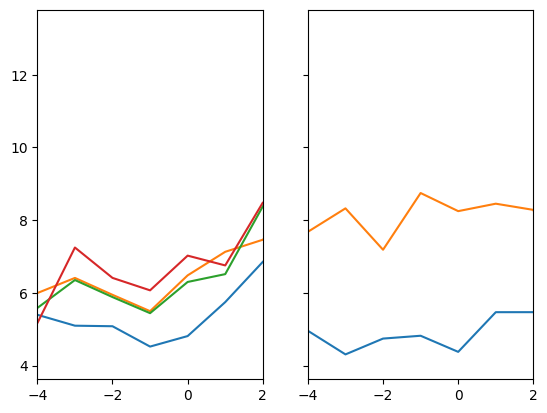

In [75]:
fig, ax= plt.subplots(1,2, sharex=True, sharey=True)
ax[0].plot(rel_bins, avg_shifts['ctrl']['nov'][True]['rel_pos'])
ax[0].plot(rel_bins, avg_shifts['ctrl']['nov'][False]['rel_pos'])

ax[0].plot(rel_bins, avg_shifts['ko']['nov'][True]['rel_pos'])
ax[0].plot(rel_bins, avg_shifts['ko']['nov'][False]['rel_pos'])


ax[1].plot(rel_bins, avg_shifts['ctrl']['fam'][True]['rel_pos'])
ax[1].plot(rel_bins, avg_shifts['ctrl']['fam'][False]['rel_pos'])

ax[0].set_xlim([-4,2])


/tmp/ipykernel_306035/2370393189.py:2: RuntimeWarning: Mean of empty slice
  mu, sem = np.nanmean(avg_shifts['ctrl']['nov'][True]['rel_pos'], axis=0), sp.stats.sem(avg_shifts['ctrl']['nov'][True]['rel_pos'], axis=0)
/tmp/ipykernel_306035/2370393189.py:6: RuntimeWarning: Mean of empty slice
  mu, sem = np.nanmean(avg_shifts['ko']['nov'][True]['rel_pos'], axis=0), sp.stats.sem(avg_shifts['ko']['nov'][True]['rel_pos'], axis=0)
/tmp/ipykernel_306035/2370393189.py:10: RuntimeWarning: Mean of empty slice
  mu, sem = np.nanmean(avg_shifts['ctrl']['fam'][True]['rel_pos'], axis=0), sp.stats.sem(avg_shifts['ctrl']['fam'][True]['rel_pos'], axis=0)
/tmp/ipykernel_306035/2370393189.py:14: RuntimeWarning: Mean of empty slice
  mu, sem = np.nanmean(avg_shifts['ko']['fam'][True]['rel_pos'], axis=0), sp.stats.sem(avg_shifts['ko']['fam'][True]['rel_pos'], axis=0)
/tmp/ipykernel_306035/2370393189.py:20: RuntimeWarning: Mean of empty slice
  mu, sem = np.nanmean(avg_shifts['ctrl']['nov'][False]['rel_pos']

(-4.0, 2.0)

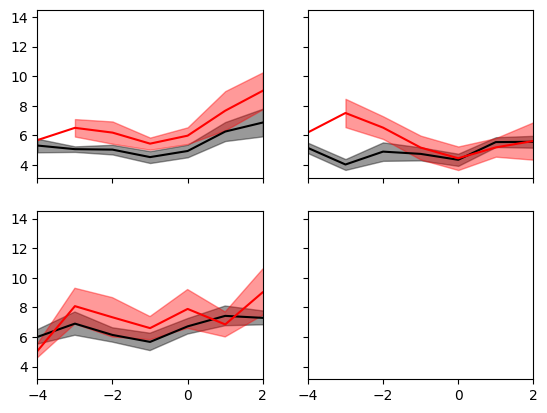

In [61]:
fig, ax = plt.subplots(2,2, sharey=True, sharex=True)
mu, sem = np.nanmean(avg_shifts['ctrl']['nov'][True]['rel_pos'], axis=0), sp.stats.sem(avg_shifts['ctrl']['nov'][True]['rel_pos'], axis=0)
ax[0, 0].plot(rel_bins, mu, color='black')
ax[0, 0].fill_between(rel_bins, mu-sem, mu+sem, color='black', alpha=.4)

mu, sem = np.nanmean(avg_shifts['ko']['nov'][True]['rel_pos'], axis=0), sp.stats.sem(avg_shifts['ko']['nov'][True]['rel_pos'], axis=0)
ax[0, 0].plot(rel_bins, mu, color='red')
ax[0, 0].fill_between(rel_bins, mu-sem, mu+sem, color='red', alpha=.4)

mu, sem = np.nanmean(avg_shifts['ctrl']['fam'][True]['rel_pos'], axis=0), sp.stats.sem(avg_shifts['ctrl']['fam'][True]['rel_pos'], axis=0)
ax[0, 1].plot(rel_bins, mu, color='black')
ax[0, 1].fill_between(rel_bins, mu-sem, mu+sem, color='black', alpha=.4)

mu, sem = np.nanmean(avg_shifts['ko']['fam'][True]['rel_pos'], axis=0), sp.stats.sem(avg_shifts['ko']['fam'][True]['rel_pos'], axis=0)
ax[0, 1].plot(rel_bins, mu, color='red')
ax[0, 1].fill_between(rel_bins, mu-sem, mu+sem, color='red', alpha=.4)


# 
mu, sem = np.nanmean(avg_shifts['ctrl']['nov'][False]['rel_pos'], axis=0), sp.stats.sem(avg_shifts['ctrl']['nov'][False]['rel_pos'], axis=0)
ax[1, 0].plot(rel_bins, mu, color='black')
ax[1, 0].fill_between(rel_bins, mu-sem, mu+sem, color='black', alpha=.4)

mu, sem = np.nanmean(avg_shifts['ko']['nov'][False]['rel_pos'], axis=0), sp.stats.sem(avg_shifts['ko']['nov'][False]['rel_pos'], axis=0)
ax[1, 0].plot(rel_bins, mu, color='red')
ax[1, 0].fill_between(rel_bins, mu-sem, mu+sem, color='red', alpha=.4)

# mu, sem = np.nanmean(avg_shifts['ctrl']['fam'][False], axis=0), sp.stats.sem(avg_shifts['ctrl']['fam'][False], axis=0)
# ax[1, 1].plot(bins, mu, color='black')
# ax[1, 1].fill_between(bins, mu-sem, mu+sem, color='black', alpha=.4)

# mu, sem = np.nanmean(avg_shifts['ko']['fam'][False], axis=0), sp.stats.sem(avg_shifts['ko']['fam'][False], axis=0)
# ax[1, 1].plot(bins, mu, color='red')
# ax[1, 1].fill_between(bins, mu-sem, mu+sem, color='red', alpha=.4)

ax[0,0].set_xlim([-4,2])


In [45]:
np.unique(shift_bins)

array([ 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25,
       26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38])

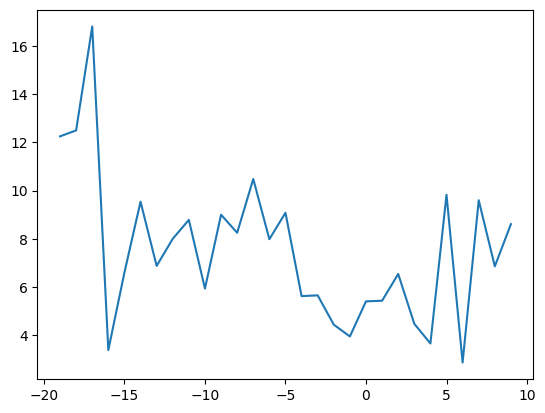

In [46]:
fig, ax = plt.subplots()
ax.plot(bins, avg_shift)